# NDT7 EDA — Cambodia Broadband & Mobile/Cellular (Combined)

Full exploratory analysis of Cambodia NDT7 (M-Lab) data, mirroring the structure of
`notebooks/ookla/cambodia_eda.ipynb` (Fixed Broadband + Mobile/Cellular, same threshold and
plotting sections) so results are directly comparable section-by-section, and mirroring the
prep/EDA split established by `notebooks/ndt7/vietnam_ndt7_prep.ipynb` /
`vietnam_eda.ipynb`.

**Input:** `data/exports/ndt7_cambodia_province_quarterly.csv` (Broadband) and
`data/exports/ndt7_cambodia_mobile_province_quarterly.csv` (Mobile) — both produced by
`cambodia_ndt7_prep.ipynb` (tile-binned at Ookla's zoom-16 resolution, `is_reliable` computed
with the same `total_tests>=100 & n_tiles>=5` threshold used by every Ookla country notebook
and by `vietnam_ndt7_prep.ipynb`, merged with `data/reference/cambodia_reference.csv`). This
notebook does no raw-data processing — it picks up where the prep notebook leaves off.

**Known result, stated up front:** unlike Vietnam (28.6% of province-quarters reliable,
decaying from ~48% to ~11% over the study period), **0% of Cambodia's province-quarters clear
the `n_tiles>=5` bar, for both Broadband and Mobile.** This is a structural data-volume
problem, not a bug: NDT7's geolocation here is city-level (one lat/lon per city, not per
device — see `data/ndt7/kh/README_for_eda.md`), so raw points collapse into very few zoom-16
tiles regardless of test volume. Cambodia has 750K raw records but only 47 distinct tiles
nationwide across all 3 years (~2/province) — Vietnam has 22M records → 856 tiles, which is
what let it clear `n_tiles>=5` at all. The threshold is kept identical to every other
country/source in this study (see `docs/paper_draft.md` Contributions: "a reliability
threshold applied consistently, not just computed") rather than loosened for Cambodia alone;
the sections below therefore run on an empty reliable-filtered dataset by design, and each
section reports that explicitly instead of silently producing empty plots.

## Province Reference Data

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../../data/reference/cambodia_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))

Provinces loaded: 25
Regions: ['Capital', 'Center', 'East', 'North', 'Northeast', 'Northwest', 'South', 'Southeast', 'Southwest', 'West']

        province_en    region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
    Bantey Meanchey Northwest    898484              135                199216.96              1
         Battambang Northwest   1132017               97                199216.96              2
       Kampong Cham      East   1062914              234                199216.96              4
    Kampong Chhnang    Center    604895              110                199216.96              1
       Kampong Speu Southwest    924175              132                199216.96              4
       Kampong Thom    Center    807254               58                199216.96              3
             Kampot Southwest    682987              140                199216.96              2
             Kandal    Center   1352198              425                199216.96    

### Population and GDP by Region — Summary

In [2]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())

           provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                  
Capital            1         2.35       3465.0             199217.0             199217.0
Center             3         2.76        198.0             199217.0             199217.0
East               5         3.77        143.0             199217.0             199217.0
North              2         0.52         30.0             199217.0             199217.0
Northeast          2         0.41         19.0             199217.0             199217.0
Northwest          3         3.13        113.0             199217.0             199217.0
South              3         1.38        191.0             199217.0             199217.0
Southeast          1         0.61        207.0             199217.0             199217.0
Southwest          3         1.75         95.0             199217.0             199217.0
West               2 

### GDP per Capita vs Population Density — by Region

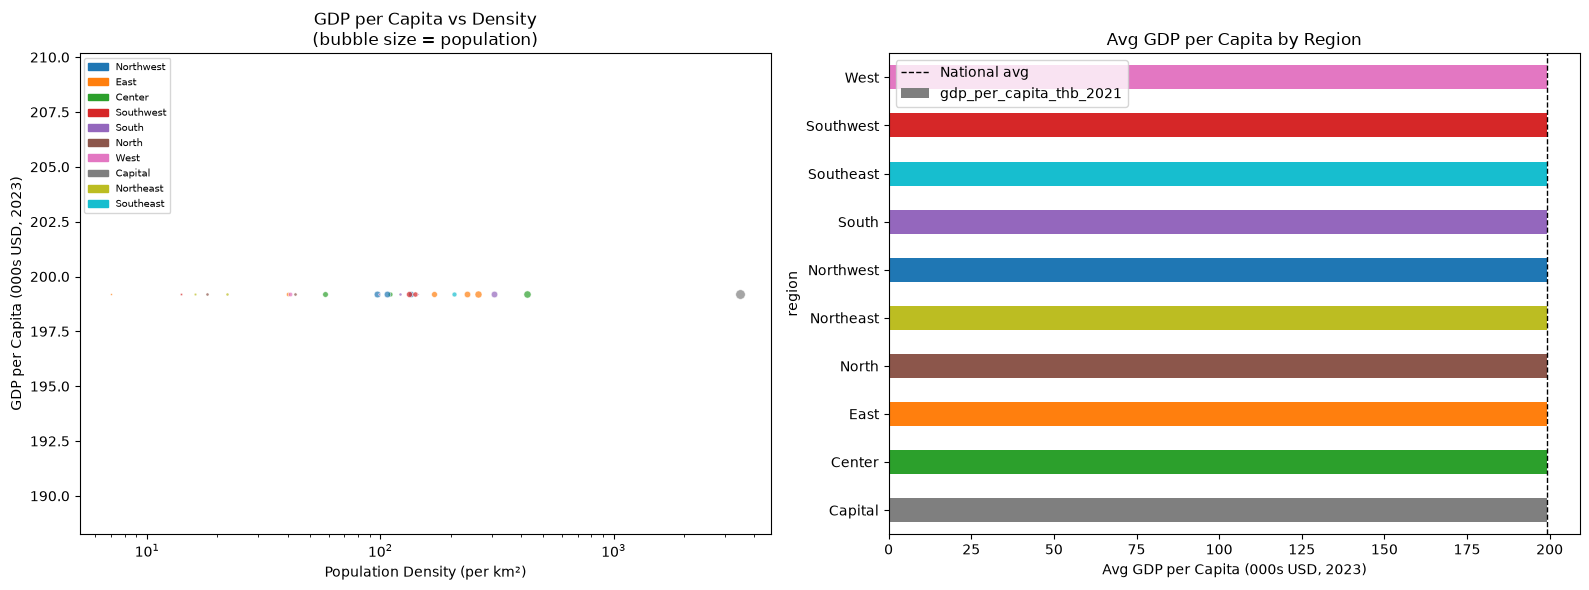

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('../../../outputs/ndt7/cambodia', exist_ok=True)
plt.savefig('../../../outputs/ndt7/cambodia/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()

### Internet Tier Distribution — Assumptions Map

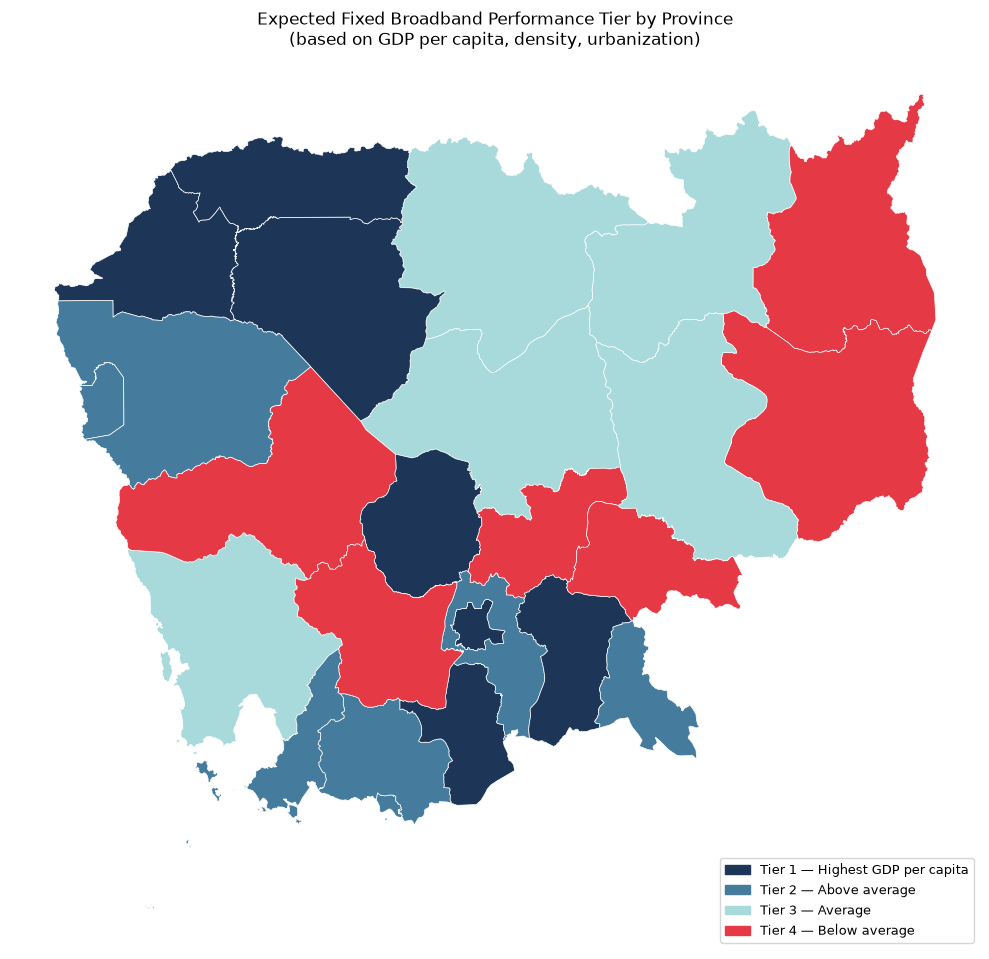

In [4]:
CAMBODIA_GEOJSON = '../../../data/geo/cambodia_provinces.geojson'
thailand_gdf = gpd.read_file(CAMBODIA_GEOJSON).to_crs(4326)

tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()
geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig('../../../outputs/ndt7/cambodia/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()

### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [5]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))

=== TOP 10 by GDP per Capita ===
    province_en    region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bantey Meanchey Northwest    898484                199216.96              1
     Battambang Northwest   1132017                199216.96              2
   Kampong Cham      East   1062914                199216.96              4
Kampong Chhnang    Center    604895                199216.96              1
   Kampong Speu Southwest    924175                199216.96              4
   Kampong Thom    Center    807254                199216.96              3
         Kampot Southwest    682987                199216.96              2
         Kandal    Center   1352198                199216.96              2
            Kep     South     48772                199216.96              2
       Koh Kong Southwest    140962                199216.96              3

=== BOTTOM 10 by GDP per Capita ===
    province_en    region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bantey Meanchey No

---
# Part 1 — Broadband

## Full EDA — NDT7 Broadband, Cambodia (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [6]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_cambodia_province_quarterly.csv'
GEOJSON  = '../../../data/geo/cambodia_provinces.geojson'
PROV_REF = '../../../data/reference/cambodia_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (151, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  22 (of 25 in reference — NDT7 has zero test volume for the rest)


In [7]:
# is_reliable already computed upstream (cambodia_ndt7_prep.ipynb, same total_tests>=100 & n_tiles>=5 threshold)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\nUnlike Vietnam (28.6% overall), Cambodia clears n_tiles>=5 in ZERO quarters — see notebook intro "
      "for why (city-level geolocation + ~48x less raw volume than Vietnam caps distinct tiles at 47 nationwide).")

Reliable province-quarters per label:
label
2023-Q1    0
2023-Q2    0
2023-Q3    0
2023-Q4    0
2024-Q1    0
2024-Q2    0
2024-Q3    0
2024-Q4    0
2025-Q1    0
2025-Q2    0
2025-Q3    0
2025-Q4    0

Overall reliable: 0 / 151 (0.0%)

Unlike Vietnam (28.6% overall), Cambodia clears n_tiles>=5 in ZERO quarters — see notebook intro for why (city-level geolocation + ~48x less raw volume than Vietnam caps distinct tiles at 47 nationwide).


### 2. Data Quality — Coverage per Province

In [8]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 300 | Actual: 151 | Missing: 149

Provinces with ZERO NDT7 test volume in any quarter (3): ['Kratie', 'Oddar Meanchey', 'Stung Treng']

Low-test quarters (< 100 tests) — 114 of 151 province-quarter rows
           name   label  total_tests  n_tiles
         Kandal 2023-Q4          3.0      1.0
      Prey Veng 2024-Q2          3.0      1.0
     Mondulkiri 2024-Q1          3.0      1.0
Bantey Meanchey 2024-Q2          3.0      1.0
   Kampong Cham 2025-Q1          3.0      1.0
       Koh Kong 2024-Q4          3.0      1.0
   Kampong Cham 2024-Q4          3.0      1.0
   Kampong Speu 2024-Q4          3.0      1.0
   Kampong Speu 2025-Q3          3.0      1.0
 Preah Sihanouk 2025-Q1          3.0      1.0
         Pursat 2023-Q3          4.0      1.0
         Pursat 2025-Q3          4.0      1.0
   Kampong Cham 2023-Q4          4.0      1.0
       Koh Kong 2023-Q1          4.0      1.0
     Svay Rieng 2023-Q3          4.0      1.0


In [9]:
# Drop unreliable province-quarters before any stats/plots use master downstream — same rule as every
# other country/source. For Cambodia this empties master entirely (0 reliable rows); sections below
# report that explicitly rather than silently rendering blank charts.
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 0 rows kept

No province-quarters clear the reliability threshold — sections 3-14 below will report 'no reliable data' instead of plotting.


### 3. Speed Distribution — All Provinces, All Quarters

In [10]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/cambodia/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

No reliable data for Broadband — skipping speed-distribution plot.


### 4. Province Ranking — Mean Download Speed (All Quarters)

In [11]:
region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Broadband — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Broadband — skipping province-ranking plot.


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

In [12]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Broadband — skipping heatmap.


### 6. Regional Comparison — Download, Upload, Latency

In [13]:
region_order = ['Northwest', 'East', 'Center', 'Southwest', 'South', 'North', 'West', 'Capital', 'Northeast', 'Southeast']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Broadband — skipping regional boxplot.


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

In [14]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Broadband — skipping time-series trend plot.


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

In [15]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Broadband — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Broadband Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

No reliable data for Broadband — skipping GDP/density correlation plot.


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [16]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

No reliable data for Broadband — skipping multivariate model (need >=5 observations to fit).


### 9. Upload/Download Ratio — Symmetry Check

In [17]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
    print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

No reliable data for Broadband — skipping UL/DL ratio plot.


### 10. Province Summary — Tier & UL/DL Ratio

In [18]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Broadband — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

No reliable data for Broadband — skipping province summary.


### 12. Full Province Summary Table

In [19]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

No reliable data for Broadband — nothing to summarize.


### 13. UL/DL Symmetry — Fiber Penetration Evidence

In [20]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Broadband', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Broadband — skipping UL/DL symmetry deep-dive.


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

In [21]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Broadband — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/cambodia/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

No reliable data for Broadband — skipping temporal growth plot.


### 16. EDA Key Findings Summary

## Key Findings from EDA

- **Reliability: 0% of Cambodia Broadband province-quarters clear `n_tiles>=5`** — a
  structural consequence of city-level NDT7 geolocation combined with Cambodia's much smaller
  raw-record volume relative to Vietnam (see notebook intro). Every plot in this section is
  therefore empty by design, not by error.
- No downstream comparison (tier expectation, GDP/density regression, regional pattern) can be
  drawn from this dataset under the study's consistent reliability threshold.
- This result itself is the finding: NDT7 cross-validation is only viable for
  higher-volume countries (Vietnam partially; Thailand has its own dedicated pipeline).
  Cambodia, Myanmar, and Laos NDT7 data likely face the same volume ceiling and should be
  checked before assuming they'll fare better.

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [22]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_broadband_cambodia_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_cambodia_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 0 rows (reliable-only) -> ../../../data/exports/ndt7_broadband_cambodia_reliable_province_quarterly.csv
(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output 'ndt7_cambodia_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)


---
# Part 2 — Mobile/Cellular

## Full EDA — NDT7 Mobile/Cellular, Cambodia (2023 Q1 – 2025 Q4)

### 1. Load Province x Quarter Data

In [23]:
import warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

NDT7_CSV = '../../../data/exports/ndt7_cambodia_mobile_province_quarterly.csv'
GEOJSON  = '../../../data/geo/cambodia_provinces.geojson'
PROV_REF = '../../../data/reference/cambodia_reference.csv'

Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)

master = pd.read_csv(NDT7_CSV)
master = master.rename(columns={'province': 'name', 'quarter': 'label', 'quarter.1': 'quarter'})
master['month'] = master['quarter'].map(Q_TO_MONTH)
master['period_start'] = pd.to_datetime(dict(year=master['year'], month=master['month'], day=1))

prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']

print(f"Master shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} -> {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()} (of {len(prov_ref)} in reference — NDT7 has zero test volume for the rest)")

Master shape: (43, 19)
Date range: 2023-01-01 -> 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  10 (of 25 in reference — NDT7 has zero test volume for the rest)


In [24]:
# is_reliable already computed upstream (cambodia_ndt7_prep.ipynb, same total_tests>=100 & n_tiles>=5 threshold)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")
print("\nUnlike Vietnam (28.6% overall), Cambodia clears n_tiles>=5 in ZERO quarters — see notebook intro "
      "for why (city-level geolocation + ~48x less raw volume than Vietnam caps distinct tiles at 47 nationwide).")

Reliable province-quarters per label:
label
2023-Q1    0
2023-Q2    0
2023-Q3    0
2023-Q4    0
2024-Q1    0
2024-Q2    0
2024-Q3    0
2024-Q4    0
2025-Q1    0
2025-Q2    0
2025-Q3    0
2025-Q4    0

Overall reliable: 0 / 43 (0.0%)

Unlike Vietnam (28.6% overall), Cambodia clears n_tiles>=5 in ZERO quarters — see notebook intro for why (city-level geolocation + ~48x less raw volume than Vietnam caps distinct tiles at 47 nationwide).


### 2. Data Quality — Coverage per Province

In [25]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows (if every province had every quarter): {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

all_provinces = set(thailand_gdf['name'])
provinces_with_data = set(master['name'].unique())
zero_coverage = sorted(all_provinces - provinces_with_data)
if zero_coverage:
    print(f"\nProvinces with ZERO NDT7 test volume in any quarter ({len(zero_coverage)}): {zero_coverage}")
else:
    print("\nEvery province has at least some NDT7 data in at least one quarter.")

low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} of {len(master)} province-quarter rows")
print(low_test.head(15).to_string(index=False))

Expected rows (if every province had every quarter): 300 | Actual: 43 | Missing: 257

Provinces with ZERO NDT7 test volume in any quarter (15): ['Bantey Meanchey', 'Battambang', 'Kampong Cham', 'Kampong Chhnang', 'Kampong Speu', 'Kampot', 'Kep', 'Koh Kong', 'Kratie', 'Mondulkiri', 'Oddar Meanchey', 'Preah Vihear', 'Stung Treng', 'Svay Rieng', 'Tbong Khmum']

Low-test quarters (< 100 tests) — 18 of 43 province-quarter rows
               name   label  total_tests  n_tiles
             Kandal 2025-Q4          3.0      1.0
             Pursat 2023-Q1          5.0      1.0
     Preah Sihanouk 2024-Q3          6.0      1.0
             Pailin 2023-Q3         10.0      1.0
     Preah Sihanouk 2025-Q2         11.0      1.0
             Pailin 2023-Q2         13.0      1.0
             Kandal 2025-Q3         14.0      1.0
              Takeo 2023-Q3         15.0      1.0
              Takeo 2023-Q4         18.0      2.0
Ratanakiri Province 2025-Q1         19.0      1.0
             Kandal 2024

In [26]:
# Drop unreliable province-quarters before any stats/plots use master downstream — same rule as every
# other country/source. For Cambodia this empties master entirely (0 reliable rows); sections below
# report that explicitly rather than silently rendering blank charts.
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")
HAS_RELIABLE_DATA = len(master) > 0
if not HAS_RELIABLE_DATA:
    print("\nNo province-quarters clear the reliability threshold — sections 3-14 below will report "
          "'no reliable data' instead of plotting.")

Filtered to reliable province-quarters: 0 rows kept

No province-quarters clear the reliability threshold — sections 3-14 below will report 'no reliable data' instead of plotting.


### 3. Speed Distribution — All Provinces, All Quarters

In [27]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping speed-distribution plot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
    axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
    axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

    axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
    axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
    axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

    axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
    axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
    axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

    plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()

    plt.savefig('../../../outputs/ndt7/cambodia/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))

No reliable data for Mobile/Cellular — skipping speed-distribution plot.


### 4. Province Ranking — Mean Download Speed (All Quarters)

In [28]:
region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

if not HAS_RELIABLE_DATA:
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests'])
    print("No reliable data for Mobile/Cellular — skipping province-ranking plot.")
else:
    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 22))
    colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
    bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')
    for bar, val in zip(bars, prov_mean['mean_dl']):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=7)
    ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
    patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=9)
    ax.set_xlabel('Mean Download Speed (Mbps)')
    ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Mobile/Cellular — skipping province-ranking plot.


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

In [29]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping heatmap.")
else:
    pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
    pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
    pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

    fig, ax = plt.subplots(figsize=(16, 22))
    im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)
    ax.set_xticks(range(len(pivot_dl.columns)))
    ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot_dl.index)))
    ax.set_yticklabels(pivot_dl.index, fontsize=8)
    ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Mobile/Cellular — skipping heatmap.


### 6. Regional Comparison — Download, Upload, Latency

In [30]:
region_order = ['Northwest', 'East', 'Center', 'Southwest', 'South', 'North', 'West', 'Capital', 'Northeast', 'Southeast']

if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping regional boxplot.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, metric, label, color_key in [
        (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
        (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
        (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
    ]:
        data = [master[master['region']==r][metric].dropna().values for r in region_order]
        bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color='white', linewidth=2))
        for patch, region in zip(bp['boxes'], region_order):
            patch.set_facecolor(region_colors[region])
            patch.set_alpha(0.85)
        ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
        ax.set_ylabel(label)
        ax.set_title(f'{label} by Region')
    plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Mobile/Cellular — skipping regional boxplot.


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

In [31]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping time-series trend plot.")
else:
    latest_q = master['label'].max()
    latest = master[master['label'] == latest_q]
    top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
    bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    groups = [
        (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
        (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
    ]
    for ax, (title, provinces, base_color) in zip(axes, groups):
        for prov in provinces:
            df_p = master[master['name']==prov].sort_values('label')
            if df_p.empty: continue
            ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5, label=prov, linewidth=1.8)
        ax.set_ylabel('Avg Download (Mbps)')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Mobile/Cellular — skipping time-series trend plot.


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

In [32]:
if not HAS_RELIABLE_DATA:
    corr_df = pd.DataFrame(columns=['name','region','mean_dl','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2'])
    r, p, r2, p2 = float('nan'), float('nan'), float('nan'), float('nan')
    print("No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.")
else:
    corr_df = prov_mean.merge(
        prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'], 'gray')
        axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                        color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
    y = corr_df.loc[x.index,'mean_dl']
    if x.nunique() > 1:
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xline = np.linspace(x.min(), x.max(), 100)
        axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
        ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
    else:
        r, p = float('nan'), float('nan')
        axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
        ols_handle = []
    axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
    axes[0].set_ylabel('Mean Download Speed (Mbps)')
    axes[0].set_title('GDP per Capita vs Avg Download Speed')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches+ols_handle, fontsize=7)

    for _, row in corr_df.iterrows():
        c = region_colors.get(row['region'],'gray')
        axes[1].scatter(row['density_per_km2'], row['mean_dl'], color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
        if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
            axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']), fontsize=6.5, ha='left', va='bottom')

    x2 = corr_df['density_per_km2'].dropna()
    y2 = corr_df.loc[x2.index,'mean_dl']
    if x2.nunique() > 1:
        s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
        xline2 = np.linspace(x2.min(), x2.max(), 200)
        axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
    else:
        r2, p2 = float('nan'), float('nan')
    axes[1].set_xlabel('Population Density (per km²)')
    axes[1].set_xscale('log')
    axes[1].set_ylabel('Mean Download Speed (Mbps)')
    axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
    axes[1].legend(fontsize=7)

    plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
    print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")

No reliable data for Mobile/Cellular — skipping GDP/density correlation plot.


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together

In [33]:
import statsmodels.formula.api as smf

if not HAS_RELIABLE_DATA or len(corr_df.dropna(subset=['mean_dl'])) < 5:
    print("No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).")
else:
    model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
    model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
    model_df['log_density'] = np.log1p(model_df['density_per_km2'])

    terms = []
    if model_df['log_gdp'].nunique() > 1:
        terms.append('log_gdp')
    if model_df['log_density'].nunique() > 1:
        terms.append('log_density')
    if model_df['internet_tier'].nunique() > 1:
        terms.append("C(internet_tier)")
    if model_df['region'].nunique() > 1:
        terms.append('C(region)')

    if not terms:
        print("No varying predictors — skipping multivariate model.")
    else:
        formula = 'mean_dl ~ ' + ' + '.join(terms)
        mv_model = smf.ols(formula, data=model_df).fit()
        print(mv_model.summary())
        print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
        print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")

No reliable data for Mobile/Cellular — skipping multivariate model (need >=5 observations to fit).


### 9. Upload/Download Ratio — Symmetry Check

In [34]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
    ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

    fig, ax = plt.subplots(figsize=(14, 20))
    colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
    ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
    ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
    ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ax.set_xlabel('Upload / Download Ratio')
    ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
    patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
    ax.legend(handles=patches+[
        plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
        plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
    ], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

    divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
    print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
    print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))

No reliable data for Mobile/Cellular — skipping UL/DL ratio plot.


### 10. Province Summary — Tier & UL/DL Ratio

In [35]:
from scipy import stats
import numpy as np

if not HAS_RELIABLE_DATA:
    high_ratio = pd.Series(dtype=float)
    prov_mean = pd.DataFrame(columns=['name','region','mean_dl','mean_ul','mean_lat','mean_tests','mean_ratio','tier'])
    print("No reliable data for Mobile/Cellular — skipping province summary.")
else:
    master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
    high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

    prov_mean = (
        master.groupby(['name','region'])
        .agg(
            mean_dl=('avg_d_mbps','mean'),
            mean_ul=('avg_u_mbps','mean'),
            mean_lat=('avg_lat_ms_wt','mean'),
            mean_tests=('total_tests','mean'),
            mean_ratio=('ul_dl_ratio','mean'),
        )
        .reset_index()
        .sort_values('mean_dl', ascending=False)
    )
    prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

No reliable data for Mobile/Cellular — skipping province summary.


### 12. Full Province Summary Table

In [36]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — nothing to summarize.")
else:
    summary = prov_mean.merge(
        prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
        on='name', how='left'
    ).copy()
    summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
    summary = summary.sort_values('mean_dl', ascending=False).round(2)
    print(summary[[
        'name','region','internet_tier','mean_dl','mean_ul','mean_lat','ul_dl_ratio','mean_tests','gdp_per_capita_thb_2021'
    ]].to_string(index=False))

No reliable data for Mobile/Cellular — nothing to summarize.


### 13. UL/DL Symmetry — Fiber Penetration Evidence

In [37]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
    colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
    axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
    axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1, label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
    axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
    axes[0].set_xlabel('UL / DL Ratio')
    axes[0].set_title('UL/DL Symmetry Ratio by Province')
    patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
    axes[0].legend(handles=patches + [
        plt.Line2D([0],[0],color='black',ls='--',label=f"Mean {prov_mean['mean_ratio'].mean():.2f}"),
        plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
    ], fontsize=7, loc='lower right')

    axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                    prov_mean['mean_ratio'].values,
                    c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                    s=80, alpha=0.7, edgecolors='white', lw=0.5)
    for _, row in prov_mean.iterrows():
        if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1):
            density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
            if len(density):
                axes[1].annotate(row['name'], (density[0], row['mean_ratio']), fontsize=6.5, ha='left', va='bottom')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Population Density (per km², log scale)')
    axes[1].set_ylabel('UL/DL Ratio')
    axes[1].set_title('Density vs UL/DL Symmetry')
    axes[1].legend(handles=patches, fontsize=7)

    plt.suptitle('Upload/Download Symmetry — Mobile/Cellular', fontsize=13)
    plt.tight_layout()
    plt.savefig('../../../outputs/ndt7/cambodia/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

No reliable data for Mobile/Cellular — skipping UL/DL symmetry deep-dive.


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

In [38]:
if not HAS_RELIABLE_DATA:
    print("No reliable data for Mobile/Cellular — skipping temporal growth plot.")
else:
    first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
    last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
    growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

    if growth.empty:
        print("No province has both a 2023-Q1 and 2025-Q4 reliable observation — skipping growth plot.")
    else:
        growth_df = growth.reset_index()
        growth_df.columns = ['name','pct_growth']
        growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

        fig, ax = plt.subplots(figsize=(14, 20))
        colors = [region_colors.get(r,'gray') for r in growth_df['region']]
        bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8)
        ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2, label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
        for bar, val in zip(bars, growth_df['pct_growth']):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:+.0f}%', va='center', fontsize=6.5)
        patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
        ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")], fontsize=8, loc='lower right')
        ax.set_xlabel('Download Speed Growth (%)')
        ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
        plt.tight_layout()
        plt.savefig('../../../outputs/ndt7/cambodia/mobile/20_growth.png', dpi=150, bbox_inches='tight')
        plt.show()

No reliable data for Mobile/Cellular — skipping temporal growth plot.


### 16. EDA Key Findings Summary

## Key Findings from EDA

- **Reliability: 0% of Cambodia Mobile/Cellular province-quarters clear `n_tiles>=5`** — a
  structural consequence of city-level NDT7 geolocation combined with Cambodia's much smaller
  raw-record volume relative to Vietnam (see notebook intro). Every plot in this section is
  therefore empty by design, not by error.
- No downstream comparison (tier expectation, GDP/density regression, regional pattern) can be
  drawn from this dataset under the study's consistent reliability threshold.
- This result itself is the finding: NDT7 cross-validation is only viable for
  higher-volume countries (Vietnam partially; Thailand has its own dedicated pipeline).
  Cambodia, Myanmar, and Laos NDT7 data likely face the same volume ceiling and should be
  checked before assuming they'll fare better.

## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [39]:
import os
os.makedirs("../../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../../data/exports/ndt7_mobile_cambodia_reliable_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows (reliable-only) -> {PATH}")
if len(out):
    print(out.head(3).to_string())
else:
    print("(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output "
          "'ndt7_cambodia_mobile_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)")

Exported 0 rows (reliable-only) -> ../../../data/exports/ndt7_mobile_cambodia_reliable_province_quarterly.csv
(0 rows — reliable-only export is empty; use the un-filtered prep-notebook output 'ndt7_cambodia_mobile_province_quarterly.csv' for any downstream use that needs raw coverage instead of the reliable subset.)
